In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import networkx as nx
from statsmodels.tsa.api import VAR
from collections import defaultdict
import math
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns

In [ ]:
# Connect Google Drive, this code will let you log in your google account
drive.mount('/content/drive')
folder_id = '1dUuknUd6NEZZvgmRa8VGJXGCDHeRK8S1'
mounted_path = '/content/drive/MyDrive/SharedWithMe' # modified file path

if not os.path.exists(mounted_path):
  !mkdir -p "$mounted_path"
  !google_drive_downloader --id "$folder_id" --dest "$mounted_path" --recursive

%cd "$mounted_path"
!ls

Mounted at /content/drive
/content/drive/MyDrive/SharedWithMe
'0. Liquidity and Market Stress'   crypto_network.html	 lib


In [ ]:
coins = ["BTC", "DOGE", "SHIB", "USDT"]

all_melted = []

for coin in coins:

   file_name = f"/content/drive/MyDrive/SharedWithMe/0. Liquidity and Market Stress/Python Code/batch_process_minute_e_spread/panel_generator/{coin}_panels/panel_{coin}_avg_e_spread.csv"
   file_path = os.path.join(file_name)

   df = pd.read_csv(file_path)

   # We 'melt' into: Time, event_id, value
   df_m = df.melt(
        id_vars='time',
        var_name='event_id',
        value_name='value'
    )
   # Now we add columns for coin and event_type
   df_m['coin'] = coin
   #df_m['event_type'] = event_type

   # So df_m has: time, event_id, value, coin, event_type
   all_melted.append(df_m)

# Concatenate all
df_long = pd.concat(all_melted, ignore_index=True)

# df_long -> columns: [time, event_id, value, coin, event_type]

# Now pivot so that each row is (event_type, time, event_id),
# and the columns are the 4 coins [BTC, DOGE, SHIB, USDT].
df_pivot = df_long.pivot_table(
    index=['time','event_id'],
    columns='coin',
    values='value'
).reset_index()

# df_pivot now has columns:
#   event_type, Time, event_id, [BTC, DOGE, SHIB, USDT]

# Reorder columns if desired
final_cols = ['event_id', 'time', 'BTC', 'DOGE', 'SHIB', 'USDT']
df_pivot = df_pivot[final_cols]

# Any line with NA, drop it
df_pivot = df_pivot.dropna()

print(df_pivot.head(30))


coin event_id  time       BTC      DOGE      SHIB      USDT
20    event28 -1440  0.000069  0.000545  0.001454  0.000100
21    event29 -1440  0.000068  0.000303  0.001990  0.000100
23    event30 -1440  0.000039  0.000456  0.002354  0.000100
24    event31 -1440  0.000050  0.000592  0.002911  0.000100
25    event32 -1440  0.000078  0.000502  0.002959  0.000100
26    event33 -1440  0.000035  0.000421  0.002699  0.000100
27    event34 -1440  0.000057  0.000546  0.003211  0.000100
28    event35 -1440  0.000033  0.000631  0.003630  0.000100
29    event36 -1440  0.000041  0.000792  0.000396  0.000100
30    event37 -1440  0.000076  0.000829  0.000315  0.000100
31    event38 -1440  0.000043  0.000965  0.000345  0.000100
32    event39 -1440  0.000078  0.000778  0.000473  0.001001
34    event40 -1440  0.000101  0.000806  0.000922  0.001001
35    event41 -1440  0.000068  0.000349  0.001014  0.000010
36    event42 -1440  0.000097  0.000242  0.000946  0.000010
37    event43 -1440  0.000068  0.000403 

In [ ]:
# 2. Read the CSV that has the types information
csv_path = "/content/drive/MyDrive/SharedWithMe/0. Liquidity and Market Stress/Python Code/batch_process_minute_e_spread/panel_generator/event_filter(incl_ob_hour_&_types) (1).csv"
df_types = pd.read_csv(csv_path)

# 3. Merge df_pivot with df_types on "event_id" (from df_pivot) and "event_index" (from df_types)
df_merged = df_pivot.merge(
    df_types[['event_index', 'Binary Type', 'Trinary Type']],  # we only need these columns
    how='left',
    left_on='event_id',
    right_on='event_index'
)

# 4. (Optional) If you want, rename columns in df_merged for consistency:
df_merged.rename(columns={
    'Binary Type': 'binary_type',
    'Trinary Type': 'trinary_type'
}, inplace=True)

# Drop event_index column
df_merged.drop(columns=['event_index'], inplace=True)

# df_merged now has all the columns from df_pivot, plus Binary_Type and Trinary_Type
print(df_merged.head())

  event_id  time       BTC      DOGE      SHIB    USDT  binary_type  \
0  event28 -1440  0.000069  0.000545  0.001454  0.0001            0   
1  event29 -1440  0.000068  0.000303  0.001990  0.0001            1   
2  event30 -1440  0.000039  0.000456  0.002354  0.0001            0   
3  event31 -1440  0.000050  0.000592  0.002911  0.0001            1   
4  event32 -1440  0.000078  0.000502  0.002959  0.0001            1   

        trinary_type  
0       Macroeconomy  
1  Crypto-Regulation  
2       Macroeconomy  
3  Crypto-Regulation  
4        Crypto-Tech  


In [ ]:
# Split into before and after the event
df_before = df_merged[df_merged['time'] < 0]
df_after = df_merged[df_merged['time'] >= 0]
df_before.tail()

,event_id,time,BTC,DOGE,SHIB,USDT,binary_type,trinary_type
70280,event72,-1,0.000042,0.000161,0.000800,0.00001,1,Crypto-Tech
70281,event73,-1,0.000085,0.000168,0.000433,0.00001,0,Macroeconomy
70282,event74,-1,0.000082,0.000190,0.000333,0.00001,0,Macroeconomy
70283,event75,-1,0.000058,0.000188,0.000460,0.00001,1,Crypto-Regulation
70284,event76,-1,0.000041,0.000203,0.000378,0.00001,1,Crypto-Regulation


In [ ]:
#-----------------------------------------------------
# A helper function to run VAR & FEVD on a subset DataFrame
# grouped by (event_type, event_id).
# ---------------------------------------------------------
def run_var_and_fevd(df, maxlags=4, fevd_steps=10):
    """
    Group df theo (event_type, event_id).
    Cho mỗi group:
      - fit VAR(BTC,DOGE,SHIB,USDT) với lag cố định = maxlags
      - tính FEVD 10-step
      - lưu results, FEVD matrix, và params
    """
    var_results_dict = {}
    fevd_dict = {}
    params_dict = {}

    for (et, eid), subdf in df.groupby(['binary_type', 'event_id']):
        # Sort theo time, set_index
        subdf = subdf.sort_values('time').reset_index(drop=True)

        subdf = subdf[['BTC','DOGE','SHIB','USDT']].dropna()

        if len(subdf) < maxlags + 2:
            continue

        model = VAR(subdf)
        # maxlags=4, trend='c' (with intercept)
        results = model.fit(maxlags=maxlags, trend='c')

        var_results_dict[(et, eid)] = results

        params_dict[(et, eid)] = results.params

        #  FEVD
        fevd = results.fevd(fevd_steps)
        # fevd.decomp.shape = (4, 4, fevd_steps)
        # 10-step-ahead => index=9 (IF fevd_steps=10)
        arr_4x4 = fevd.decomp[:, fevd_steps - 1, :]
        coin_list = ['BTC','DOGE','SHIB','USDT']
        fevd_matrix = pd.DataFrame(arr_4x4, index=coin_list, columns=coin_list)

        fevd_dict[(et, eid)] = fevd_matrix

    return var_results_dict, fevd_dict, params_dict

In [ ]:
# ---------------------------------------------------------
# A helper function to average FEVD dictionaries
#   fevd_dict[(et,eid)] = 4x4 FEVD DataFrame
# ---------------------------------------------------------
def average_fevd(fevd_dict):
    """
    Takes a dict of FEVD matrices keyed by (event_type, event_id),
    returns:
      - fevd_avg_by_type: {event_type -> average FEVD (4x4 DataFrame)}
      - fevd_avg_overall: single 4x4 DataFrame for all event_type+id combined
    """
    from collections import defaultdict

    # 1) Group the FEVD matrices by event_type
    fevd_by_type = defaultdict(list)
    for (et, eid), mat in fevd_dict.items():
        fevd_by_type[et].append(mat)

    # 2) Average FEVD per event_type
    fevd_avg_by_type = {}
    for et, list_of_mats in fevd_by_type.items():
        mat_sum = list_of_mats[0].copy()
        for m in list_of_mats[1:]:
            mat_sum += m
        fevd_avg_by_type[et] = mat_sum / len(list_of_mats)

    # 3) Overall average across all event_types, event_ids
    all_mats = list(fevd_dict.values())
    if len(all_mats) == 0:
        fevd_avg_overall = None
    else:
        mat_sum = all_mats[0].copy()
        for m in all_mats[1:]:
            mat_sum += m
        fevd_avg_overall = mat_sum / len(all_mats)

    return fevd_avg_by_type, fevd_avg_overall

In [ ]:
# ---------------------------------------------------------
# FUNCTION 3:
#   params_dict[(et,eid)] = DataFrame params
#   -> RETURN:
#       params_avg_by_type[et] = DataFrame params AVG
#       params_avg_overall = DataFrame params AVG ALL
# ---------------------------------------------------------
def average_var_params(params_dict):
    from collections import defaultdict

    #  params GROUP BY event_type
    params_by_type = defaultdict(list)
    for (et, eid), p_df in params_dict.items():
        params_by_type[et].append(p_df)

    params_avg_by_type = {}
    for et, list_of_p in params_by_type.items():
        p_sum = list_of_p[0].copy()
        for p in list_of_p[1:]:
            p_sum += p
        params_avg_by_type[et] = p_sum / len(list_of_p)

    all_p = list(params_dict.values())
    params_avg_overall = None
    if len(all_p) > 0:
        p_sum = all_p[0].copy()
        for p in all_p[1:]:
            p_sum += p
        params_avg_overall = p_sum / len(all_p)

    return params_avg_by_type, params_avg_overall

In [ ]:
# =========================================================
# 3) Run VAR & FEVD
# =========================================================
var_results_bf, fevd_dict_bf, param_dict_bf = run_var_and_fevd(df_before, maxlags=4, fevd_steps=10)

In [ ]:
# =========================================================
# 4) AVG FEVD
# =========================================================
fevd_avg_by_type_bf, fevd_avg_overall_bf = average_fevd(fevd_dict_bf)

In [ ]:
# =========================================================
# 5) AVG VAR
# =========================================================
params_avg_by_type_bf, params_avg_overall_bf = average_var_params(param_dict_bf)


In [ ]:
## ---------------------------------------------------------
# PRINT FEVD
# ---------------------------------------------------------
print("==== FEVD Averages  ====")
print("** By event_type **")
for et, mat in fevd_avg_by_type_bf.items():
    print(f"event_type = {et}")
    print(mat)
    print()
print("** Overall **")
print(fevd_avg_overall_bf)

==== FEVD Averages  ====
** By event_type **
event_type = 0
           BTC      DOGE      SHIB      USDT
BTC   0.978171  0.014550  0.005923  0.001356
DOGE  0.049588  0.941564  0.006444  0.002404
SHIB  0.015920  0.021772  0.960430  0.001878
USDT  0.004467  0.004861  0.003030  0.987642

event_type = 1
           BTC      DOGE      SHIB      USDT
BTC   0.973505  0.014804  0.008404  0.003287
DOGE  0.049629  0.934586  0.011256  0.004529
SHIB  0.017802  0.011937  0.967237  0.003024
USDT  0.008186  0.005243  0.003897  0.982674

** Overall **
           BTC      DOGE      SHIB      USDT
BTC   0.975409  0.014700  0.007391  0.002499
DOGE  0.049612  0.937434  0.009292  0.003662
SHIB  0.017034  0.015952  0.964458  0.002556
USDT  0.006668  0.005087  0.003544  0.984701


In [ ]:
var_results_at, fevd_dict_at, param_dict_at = run_var_and_fevd(df_after, maxlags=4, fevd_steps=10)
fevd_avg_by_type_at, fevd_avg_overall_at = average_fevd(fevd_dict_at)
params_avg_by_type_at, params_avg_overall_at = average_var_params(param_dict_at)
print("==== FEVD Averages  ====")
print("** By event_type **")
for et, mat in fevd_avg_by_type_at.items():
    print(f"event_type = {et}")
    print(mat)
    print()
print("** Overall **")
print(fevd_avg_overall_at)

==== FEVD Averages  ====
** By event_type **
event_type = 0
           BTC      DOGE      SHIB      USDT
BTC   0.950754  0.032608  0.012263  0.004375
DOGE  0.088703  0.901110  0.007116  0.003071
SHIB  0.045236  0.031881  0.918522  0.004361
USDT  0.016524  0.006332  0.004017  0.973127

event_type = 1
           BTC      DOGE      SHIB      USDT
BTC   0.943519  0.025184  0.023110  0.008187
DOGE  0.085117  0.881618  0.024612  0.008652
SHIB  0.035110  0.019577  0.940720  0.004592
USDT  0.006418  0.007828  0.005443  0.980312

** Overall **
           BTC      DOGE      SHIB      USDT
BTC   0.946472  0.028214  0.018682  0.006631
DOGE  0.086581  0.889574  0.017471  0.006374
SHIB  0.039243  0.024599  0.931660  0.004498
USDT  0.010543  0.007217  0.004861  0.977379


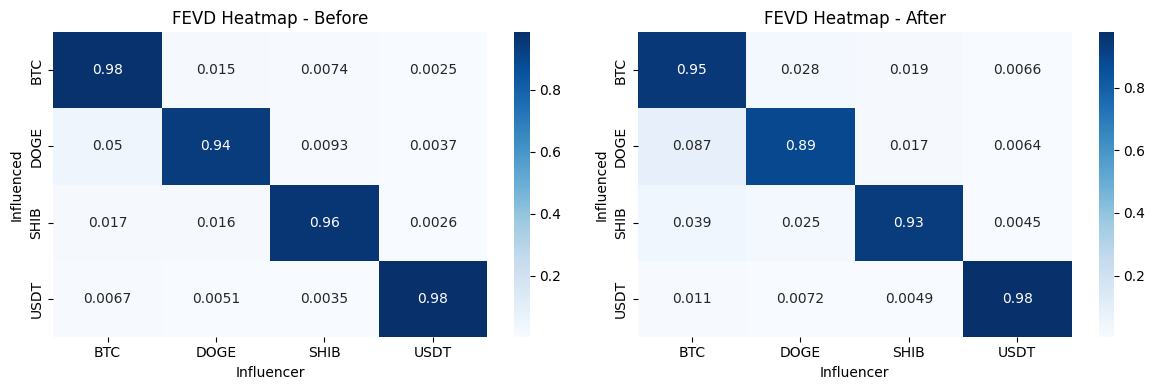

In [ ]:
# Draw beautiful chart for the FEVD matrix

plt.figure(figsize=(12, 4))

# Plot the "before" FEVD matrix
plt.subplot(1, 2, 1)
sns.heatmap(fevd_avg_overall_bf, annot=True, cmap='Blues')
plt.title('FEVD Heatmap - Before')
plt.xlabel('Influencer')
plt.ylabel('Influenced')

# Plot the "after" FEVD matrix
plt.subplot(1, 2, 2)
sns.heatmap(fevd_avg_overall_at, annot=True, cmap='Blues')
plt.title('FEVD Heatmap - After')
plt.xlabel('Influencer')
plt.ylabel('Influenced')

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()


In [ ]:
def plot_spillover_network(fevd_mat, title="", threshold_min=0.01):
    """
    Draw a spillover network diagram for an FEVD matrix (DataFrame NxN):
      - fevd_mat: a DataFrame with index & columns = coins
      - title: figure title
      - threshold_min: minimum threshold to include an edge
    """

    # 1) Prepare coins and adjacency matrix
    coins = list(fevd_mat.columns)
    n = len(coins)
    adj_matrix = fevd_mat.values  # shape (n,n)

    # 2) Create a directed graph (DiGraph)
    G = nx.DiGraph()
    for c in coins:
        G.add_node(c)

    # 3) Add edges:
    #    adj_matrix[i,j] = fraction of coin i's variance explained by coin j
    #    => interpret coin j's shock -> coin i (j->i)
    for i in range(n):
        for j in range(n):
            if i != j:
                val = adj_matrix[i, j]
                if val >= threshold_min:
                    src = coins[j]
                    tgt = coins[i]
                    G.add_edge(src, tgt, weight=val)

    # 4) Compute inflow/outflow for each coin (row sum vs. column sum)
    inflow_array  = adj_matrix.sum(axis=1)   # row sums
    outflow_array = adj_matrix.sum(axis=0)   # column sums

    # 5) Choose a layout
    pos = nx.spring_layout(G, k=1.2, seed=42)

    # 6) Draw edges with different colors/widths based on weights
    edges = G.edges(data=True)
    edge_colors = []
    edge_widths = []

    for (u, v, d) in edges:
        w = d['weight']
        # For example:
        #   w >= 0.1 => red,
        #   0.05..0.1 => green,
        #   0.01..0.05 => blue
        if w >= 0.1:
            edge_colors.append('red')
            edge_widths.append(3.0)
        elif w >= 0.05:
            edge_colors.append('green')
            edge_widths.append(2.0)
        else:
            edge_colors.append('blue')
            edge_widths.append(1.0)

    nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        width=edge_widths,
        arrowstyle='-|>',
        arrowsize=15,
        connectionstyle='arc3,rad=0.1'
    )

    # 7) Draw each node as a red/green wedge (outflow/inflow)
    ax = plt.gca()
    node_radius = 0.05

    for i, coin in enumerate(coins):
        x, y = pos[coin]
        inflow_val  = inflow_array[i]
        outflow_val = outflow_array[i]
        total = inflow_val + outflow_val
        if total > 0:
            frac_red = outflow_val / total
        else:
            frac_red = 0.5

        # Red portion (outflow)
        theta_red = 360 * frac_red
        wedge_red = mpatches.Wedge(
            center=(x, y), r=node_radius,
            theta1=0, theta2=theta_red,
            facecolor='r', zorder=3
        )
        ax.add_patch(wedge_red)

        # Green portion (inflow)
        wedge_green = mpatches.Wedge(
            center=(x, y), r=node_radius,
            theta1=theta_red, theta2=360,
            facecolor='g', zorder=3
        )
        ax.add_patch(wedge_green)

        # Node label with black text & white outline
        ax.text(
            x, y, coin,
            ha='center', va='center',
            fontsize=9,
            color='black',
            zorder=4,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")]
        )

    # 8) Manually create a legend for edge colors only
    red_line   = mlines.Line2D([], [], color='red', linewidth=3, label='Spillover ≥ 0.10')
    green_line = mlines.Line2D([], [], color='green', linewidth=2, label='0.05 ≤ Spillover < 0.10')
    blue_line  = mlines.Line2D([], [], color='blue', linewidth=1, label='0.01 ≤ Spillover < 0.05')

    plt.legend(
        handles=[red_line, green_line, blue_line],
        loc='upper left', bbox_to_anchor=(1.0, 1.0)
    )

    # Finalize
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()


def plot_all_regu_spillovers(fevd_dict_):
    """
    Loop over each (regu, event_id) -> FEVD matrix
    and plot one network figure per event.
    """
    for (et, eid), fevd_mat in fevd_dict_regu.items():
        plt.figure(figsize=(6, 6))
        t = f"Spillover for {et}, {eid}"
        plot_spillover_network(fevd_mat, title=t, threshold_min=0.01)
        plt.show()

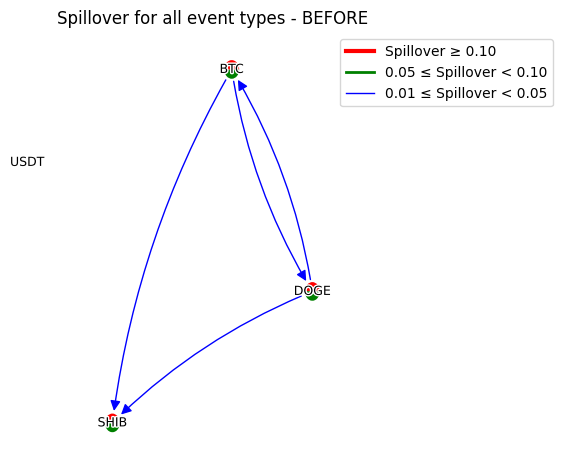

In [ ]:
plot_spillover_network(fevd_avg_overall_bf, title="Spillover for all event types - BEFORE", threshold_min=0.01)

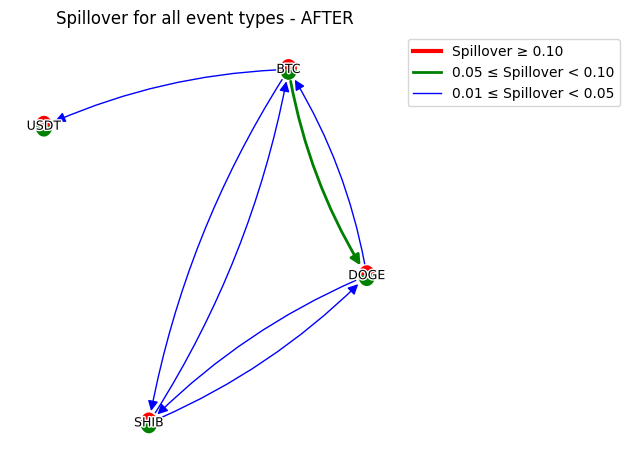

In [ ]:
plot_spillover_network(fevd_avg_overall_at, title="Spillover for all event types - AFTER", threshold_min=0.01)

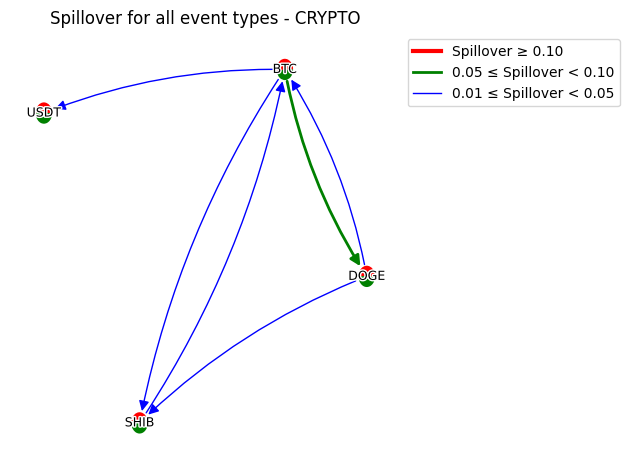

In [ ]:
plot_spillover_network(fevd_avg_by_type_at[0], title="Spillover for all event types - CRYPTO", threshold_min=0.01)


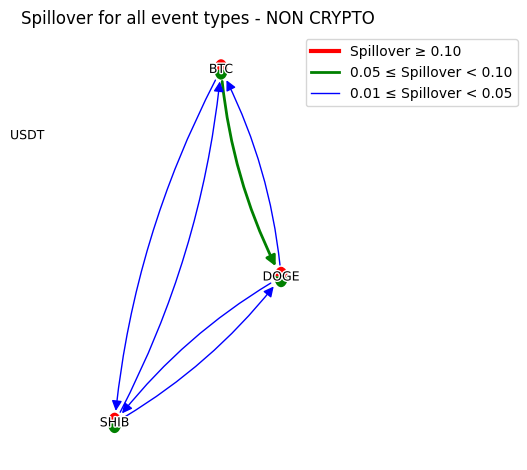

In [ ]:
plot_spillover_network(fevd_avg_by_type_at[1], title="Spillover for all event types - NON CRYPTO", threshold_min=0.01)
